# ============
# SALES CASE STUDY
# ============

# 1. Data Loading and importing of libraries

In [0]:
# Pandas is a python data analysis library used for analysing data
import pandas as pd
# Is a python library used for doing numerical analysis
import numpy as np

In [0]:
data_path ='/Workspace/Users/bkramogayane@gmail.com/Data Science work/1785258801617_Sales_Case_Study_2021_1.xlsx'

In [0]:
%pip install openpyxl

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
# read the data from a csv file to a pandas dataframe
df=pd.read_excel(data_path)

In [0]:
# This is a pandas function that allows us to view the first 10 rows of the dataframe
df.head(10)

,Date,Sales,Cost Of Sales,Quantity Sold
0,2013-12-30,223937.967870,230079.621012,6827
1,2013-12-31,300345.484564,306986.120484,9268
2,2014-01-01,86782.467727,87986.318214,2678
3,2014-01-02,200173.116753,202881.177706,6175
4,2014-01-03,326906.074176,333806.291873,10084
5,2014-01-04,307043.935422,313652.348272,9470
6,2014-01-05,179188.884488,183083.284984,5524
7,2014-01-06,306351.950859,313446.068149,9448
8,2014-01-07,224020.409968,229533.973728,6911
9,2014-01-08,101836.402236,99381.967517,2990


# 2. Exploratory Data Analysis (EDA)

In [0]:
# Check number of rows and number of columns
df.shape

(1053, 4)

In [0]:
# Check column names/titles
df.columns

Index(['Date', 'Sales', 'Cost Of Sales', 'Quantity Sold'], dtype='object')

In [0]:
# Column names and their respective data types
df.dtypes

Date             datetime64[ns]
Sales                   float64
Cost Of Sales           float64
Quantity Sold             int64
dtype: object

In [0]:
# Checking the number of NULL values in our data
df.isnull().sum()

Date             0
Sales            0
Cost Of Sales    0
Quantity Sold    0
dtype: int64

In [0]:
# Count duplicate rows
duplicate_count = df.duplicated().sum()
2
print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


In [0]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1053 entries, 0 to 1052
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           1053 non-null   datetime64[ns]
 1   Sales          1053 non-null   float64       
 2   Cost Of Sales  1053 non-null   float64       
 3   Quantity Sold  1053 non-null   int64         
dtypes: datetime64[ns](1), float64(2), int64(1)
memory usage: 33.0 KB


# 3. CREATE KPI METRICS

# KPI Dashboard
- Total Revenue
- Total Cost
- Gross Profit
- Average Selling Price
- Average Daily Quantity
- Total Units Sold
- Gross Margin %
- Monthly Revenue Growth

In [0]:
# Sales Price Per Unit
df['Unit_Price'] = df['Sales'] / df['Quantity Sold']

# Gross Profit %
df['GP_%'] = (
    (df['Sales'] - df['Cost Of Sales'])
    / df['Sales']
) * 100

# Month-Year Column
df['Month'] = df['Date'].dt.to_period('M')

In [0]:
# Daily Sales Price per Unit
df["Unit Price"] = df["Sales"] / df["Quantity Sold"]

In [0]:
#Daily Gross Profit %
df["Unit Cost"] = df["Cost Of Sales"] / df["Quantity Sold"]

df["Gross Profit Per Unit %"] = (
    (df["Unit Price"]-df["Unit Cost"])
    /df["Unit Price"]*100
)

In [0]:
# This is a pandas function that allows us to view the first 10 rows of the dataframe
df.head(10)

,Date,Sales,Cost Of Sales,Quantity Sold,Unit_Price,GP_%,Month,Unit Price,Unit Cost,Gross Profit Per Unit %
0,2013-12-30,223937.967870,230079.621012,6827,32.801812,-2.742569,2013-12,32.801812,33.701424,-2.742569
1,2013-12-31,300345.484564,306986.120484,9268,32.406720,-2.210999,2013-12,32.406720,33.123233,-2.210999
2,2014-01-01,86782.467727,87986.318214,2678,32.405701,-1.387205,2014-01,32.405701,32.855235,-1.387205
3,2014-01-02,200173.116753,202881.177706,6175,32.416699,-1.352859,2014-01,32.416699,32.855251,-1.352859
4,2014-01-03,326906.074176,333806.291873,10084,32.418294,-2.110765,2014-01,32.418294,33.102568,-2.110765
5,2014-01-04,307043.935422,313652.348272,9470,32.422802,-2.152269,2014-01,32.422802,33.120628,-2.152269
6,2014-01-05,179188.884488,183083.284984,5524,32.438248,-2.173349,2014-01,32.438248,33.143245,-2.173349
7,2014-01-06,306351.950859,313446.068149,9448,32.425058,-2.315676,2014-01,32.425058,33.175917,-2.315676
8,2014-01-07,224020.409968,229533.973728,6911,32.415050,-2.461188,2014-01,32.415050,33.212845,-2.461188
9,2014-01-08,101836.402236,99381.967517,2990,34.058997,2.410174,2014-01,34.058997,33.238116,2.410174


In [0]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,1053,2015-06-09 00:00:00,2013-12-30 00:00:00,2014-09-19 00:00:00,2015-06-09 00:00:00,2016-02-27 00:00:00,2016-11-16 00:00:00,NaN
Sales,1053.0,177502.21107,20495.113025,80697.903501,141913.38243,236305.156366,846678.388161,127548.391962
Cost Of Sales,1053.0,184260.312865,18375.052608,78096.760182,143791.478082,250572.453388,872081.585004,138912.894312
Quantity Sold,1053.0,5014.123457,508.0,2046.0,3843.0,6781.0,26410.0,3901.251594
Unit_Price,1053.0,37.072852,30.70237,34.176149,36.907283,40.328569,43.805997,3.445058
GP_%,1053.0,-0.874977,-14.857562,-6.220783,-2.153053,3.132905,14.415692,6.843107
Unit Price,1053.0,37.072852,30.70237,34.176149,36.907283,40.328569,43.805997,3.445058
Unit Cost,1053.0,37.245467,32.758257,34.799092,36.871946,39.881933,42.066407,2.692826
Gross Profit Per Unit %,1053.0,-0.874977,-14.857562,-6.220783,-2.153053,3.132905,14.415692,6.843107


In [0]:
# Average Unit Sales Price
average_price = df["Unit Price"].mean()

print(average_price)

37.07285158150709


In [0]:
# Price Elasticity of Demand
df["Price Change %"] = df["Unit Price"].pct_change()

df["Quantity Change %"] = df["Quantity Sold"].pct_change()

df["Elasticity"] = (
    df["Quantity Change %"]
    /df["Price Change %"]
)

# 4. Data Visualization

In [0]:
# Monthly Trend
df["Date"] = pd.to_datetime(df["Date"])

monthly = (
    df.groupby(df["Date"].dt.to_period("M"))
      .agg({
          "Sales":"sum",
          "Quantity Sold":"sum"
      })
)

In [0]:
# ----------------------------------------------------------
# 1. KPI SUMMARY
# ----------------------------------------------------------

total_revenue = df['Sales'].sum()
total_qty = df['Quantity Sold'].sum()
avg_price = df['Unit_Price'].mean()
avg_gp = df['GP_%'].mean()

print("="*50)
print("KPI SUMMARY")
print("="*50)
print(f"Total Revenue      : R {total_revenue:,.2f}")
print(f"Total Quantity     : {total_qty:,.0f}")
print(f"Avg Unit Price     : R {avg_price:.2f}")
print(f"Average GP %       : {avg_gp:.2f}%")

KPI SUMMARY
Total Revenue      : R 186,909,828.26
Total Quantity     : 5,279,872
Avg Unit Price     : R 37.07
Average GP %       : -0.87%


## Total Revenue
Measures overall sales performance.
Higher revenue indicates stronger business activity.

## Total Quantity Sold
Measures market demand.
Useful for production and inventory planning.

## Average Selling Price
Indicates pricing strength and positioning.

## Average Gross Profit %
Measures overall profitability.
Low or negative values suggest margin pressure.

## Executive Insight
Management should monitor these KPIs regularly because they provide an immediate view of business performance.

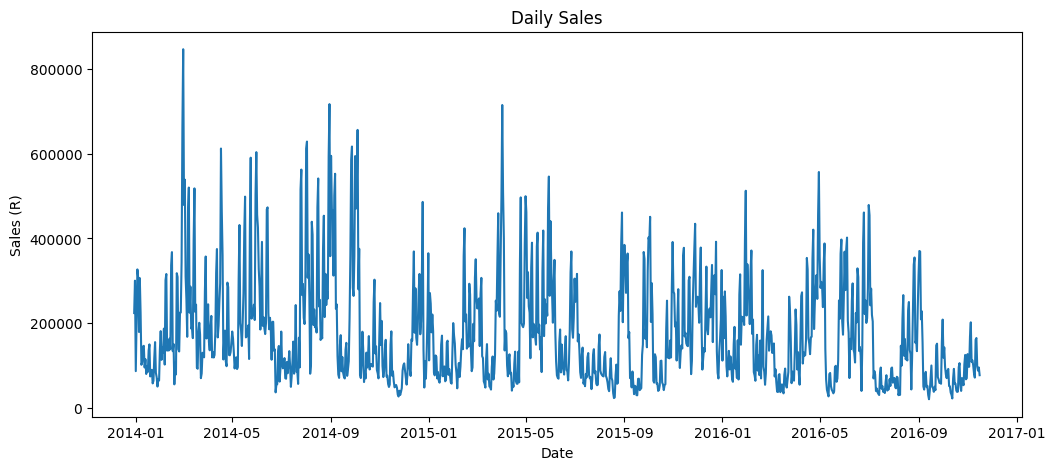

In [0]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
# ----------------------------------------------------------
# 2. Revenue Trend
# ----------------------------------------------------------
plt.figure(figsize=(12,5))
plt.plot(df["Date"], df["Sales"])
plt.title("Daily Sales")
plt.xlabel("Date")
plt.ylabel("Sales (R)")
plt.show()

# Key Findings:

- Daily sales are highly volatile, ranging from approximately R20,000 to R850,000.
- The highest sales levels occurred during 2014, indicating stronger historical performance.
- Revenue spikes suggest the presence of successful promotional campaigns.
- Demand appears price-sensitive, with increased sales occurring during lower-price periods.
- A consistent baseline level of sales indicates a stable customer base.
- Revenue peaks become less pronounced during 2015 and 2016, suggesting potential market challenges.

# Business Recommendation

Continue using targeted promotional pricing to stimulate demand while monitoring gross profit margins to ensure that increased sales volumes translate into sustainable profitability.

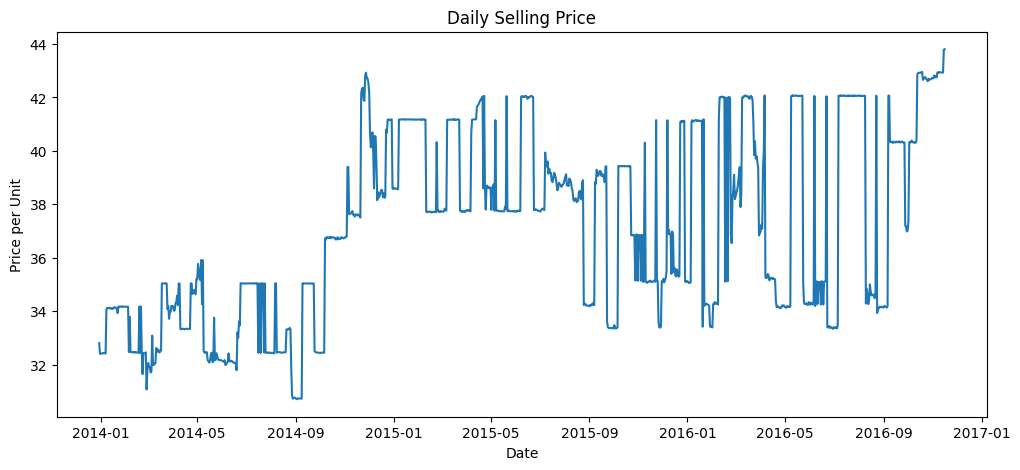

In [0]:
# ----------------------------------------------------------
# 3. Average Selling Price Trend
# ----------------------------------------------------------
plt.figure(figsize=(12,5))
plt.plot(df["Date"], df["Unit Price"])
plt.title("Daily Selling Price")
plt.xlabel("Date")
plt.ylabel("Price per Unit")
plt.show()

# Key Findings:

- Selling prices increased from approximately R32 per unit in 2014 to R44 per unit in 2016.
- The company implemented several pricing adjustments throughout the period.
- Promotional periods are clearly visible through temporary price reductions.
- Lower prices generally corresponded with increased sales volumes.
- The product displays high price elasticity, meaning customer demand is strongly influenced by price changes.
- While higher prices may improve margins, they may also reduce sales volume.

# Business Recommendation

The company should adopt an optimal pricing strategy that balances revenue growth, profitability, and customer demand. Based on the observed price elasticity, selective promotional pricing should continue because it effectively drives sales volume while maintaining market competitiveness.

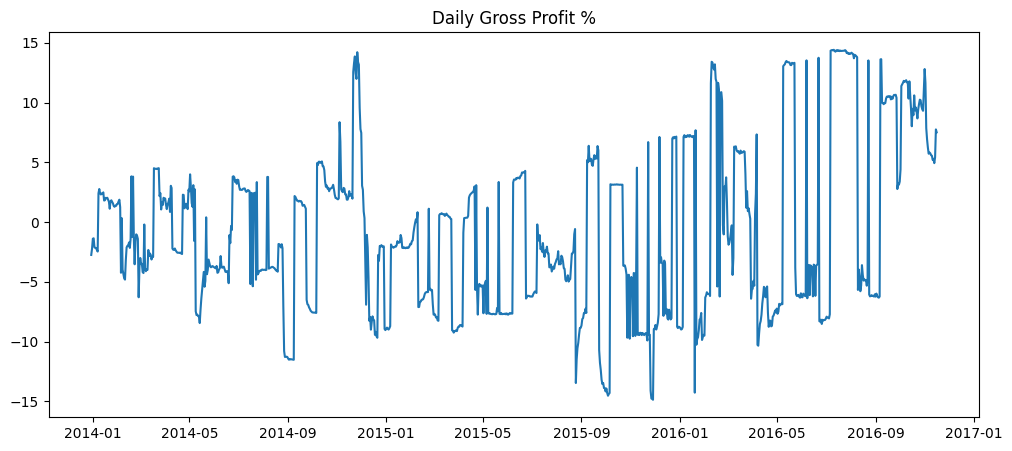

In [0]:
# ----------------------------------------------------------
# 4. Gross Profit Trend
# ----------------------------------------------------------
plt.figure(figsize=(12,5))
plt.plot(df["Date"], df["Gross Profit Per Unit %"])
plt.title("Daily Gross Profit %")
plt.show()

# Key Findings:

- Gross Profit % fluctuates significantly between approximately -15% and +15%.
- Several periods generated losses, indicating sales below cost.
- Profitability improved noticeably during 2016.
- Maximum profit margins reached approximately 15%, showing the business can achieve healthy profitability.
- Increased selling prices appear to have contributed positively to gross margins.
- Promotional pricing increased demand but often reduced profitability.

# Recommendation

The company should focus on optimizing price and cost management. While promotions effectively stimulate demand, future pricing decisions should prioritize sustainable gross profit margins to ensure long-term business performance.

In [0]:
# ----------------------------------------------------------
# 5. MONTHLY AGGREGATION
# ----------------------------------------------------------

monthly = (
    df.groupby('Month')
    .agg({
        'Sales':'sum',
        'Quantity Sold':'sum',
        'Unit_Price':'mean',
        'GP_%':'mean'
    })
    .reset_index()
)

monthly['Month'] = monthly['Month'].astype(str)

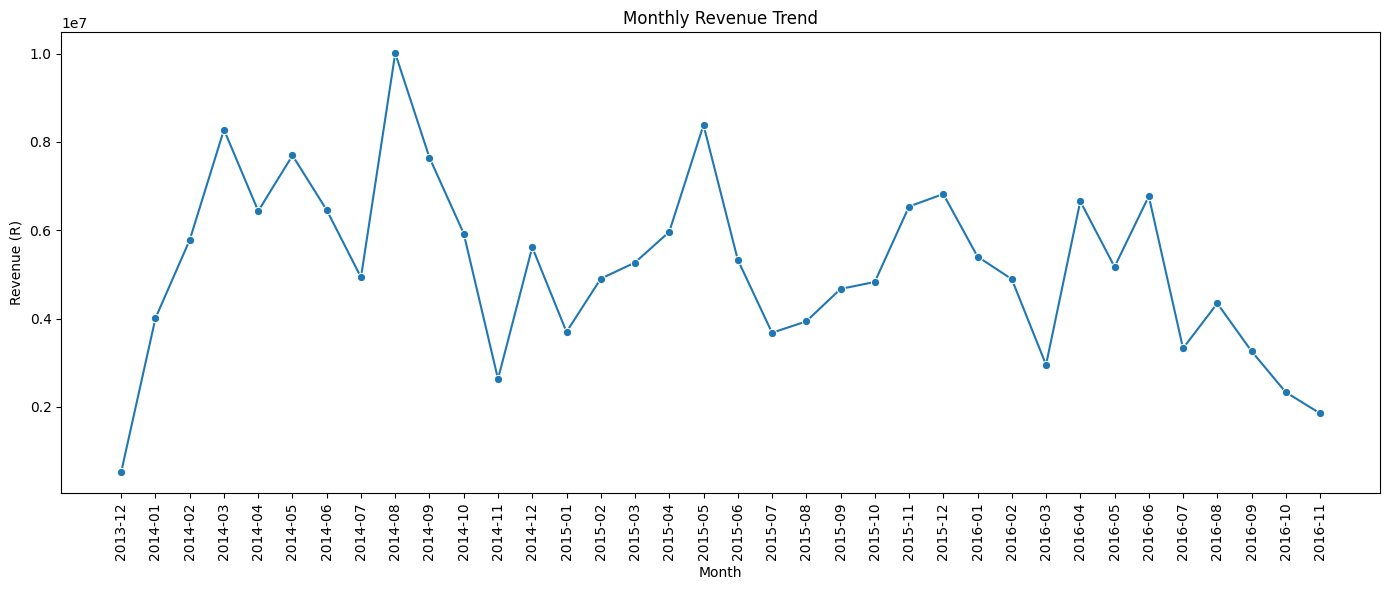

In [0]:
# ----------------------------------------------------------
# 6. MONTHLY SALES TREND
# ----------------------------------------------------------

plt.figure(figsize=(14,6))

sns.lineplot(
    data=monthly,
    x='Month',
    y='Sales',
    marker='o'
)

plt.title('Monthly Revenue Trend')
plt.xticks(rotation=90)
plt.ylabel('Revenue (R)')
plt.tight_layout()
plt.show()
# INSIGHT:
# Helps identify growth periods and seasonality.

#Interpretation
- Revenue fluctuates significantly over time, indicating periods of strong and weak demand.
- Revenue peaks typically coincide with promotional periods where lower prices stimulated higher sales volumes.
- Any sustained decline may indicate reduced customer demand, increased competition, or ineffective pricing strategies.
- The business should investigate the months with the highest revenue and replicate the conditions that drove success.

#Business Insight

Revenue growth appears to be volume-driven rather than price-driven, suggesting customers respond positively to promotional pricing.

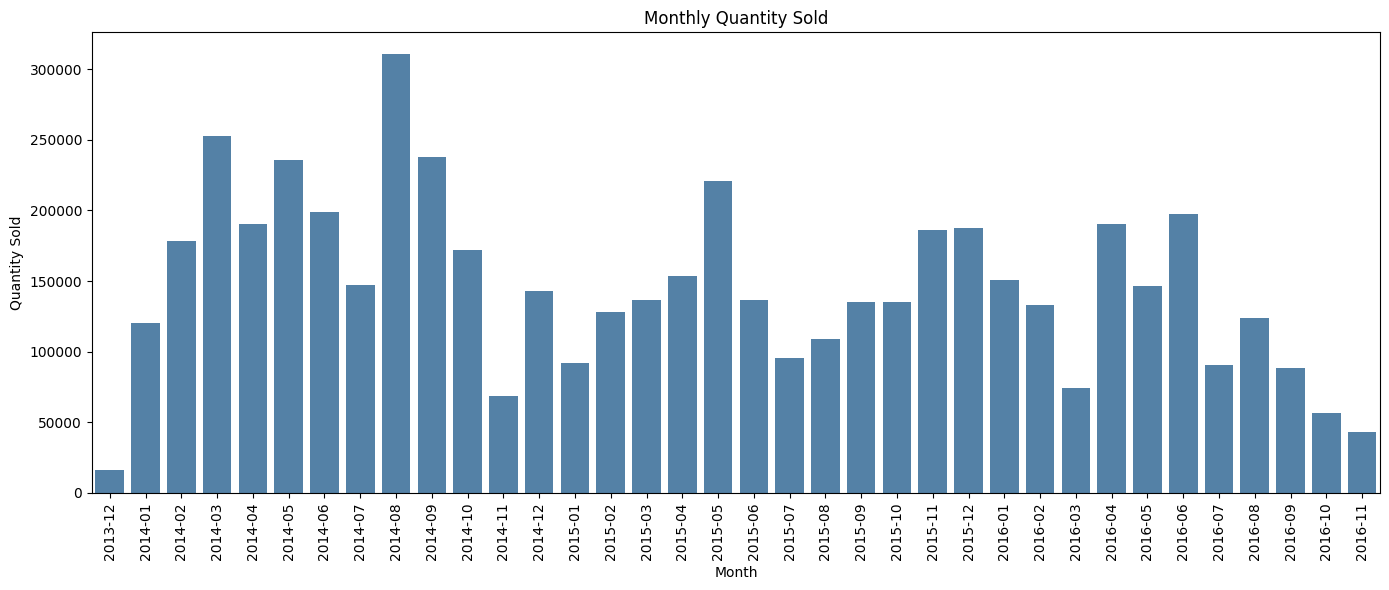

In [0]:
# ----------------------------------------------------------
# 7. MONTHLY QUANTITY SOLD
# ----------------------------------------------------------

plt.figure(figsize=(14,6))

sns.barplot(
    data=monthly,
    x='Month',
    y='Quantity Sold',
    color='steelblue'
)

plt.title('Monthly Quantity Sold')
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

# INSIGHT:
# Shows volume performance over time.

# Interpretation
- Quantity sold provides a clearer measure of customer demand than revenue alone.
- Months with unusually high sales volumes indicate strong market demand or successful promotions.
- Declining quantities may signal market saturation, customer loss, or pricing challenges.
- Comparing quantity trends against revenue trends helps determine whether growth comes from increased volume or higher selling prices.

#Business Insight

Sales volume is the primary driver of business performance and should be closely monitored when evaluating promotional campaigns.

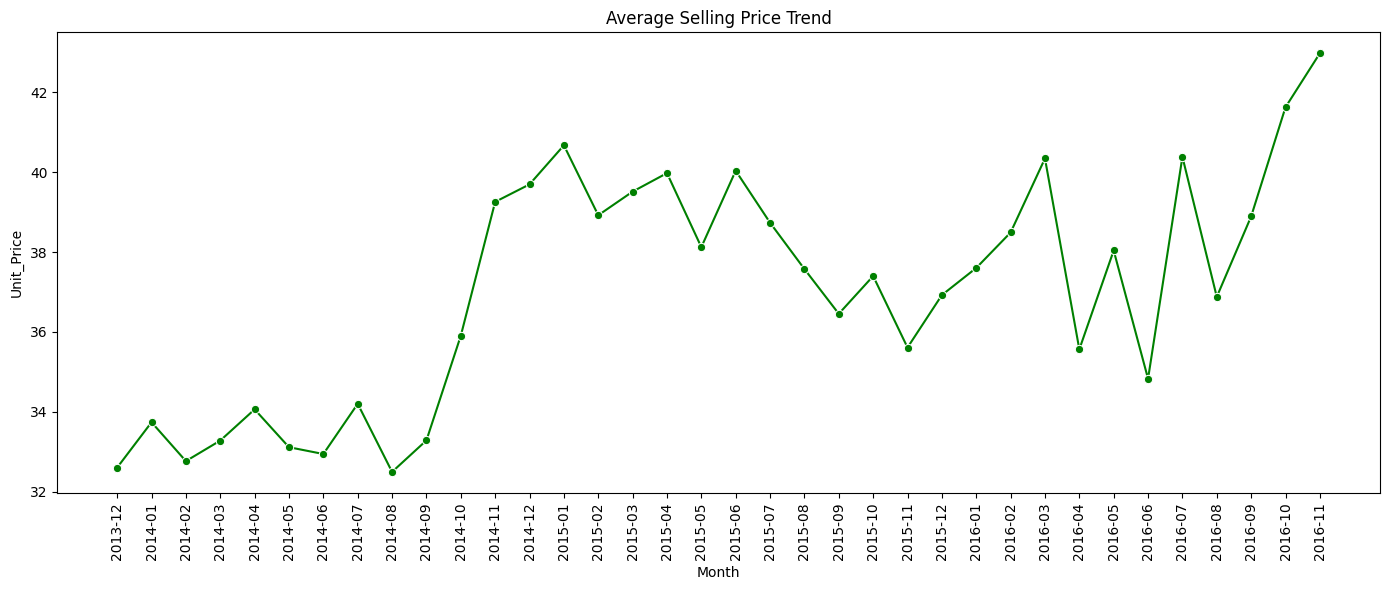

In [0]:
# ----------------------------------------------------------
# 8. AVERAGE SELLING PRICE TREND
# ----------------------------------------------------------

plt.figure(figsize=(14,6))

sns.lineplot(
    data=monthly,
    x='Month',
    y='Unit_Price',
    marker='o',
    color='green'
)

plt.title('Average Selling Price Trend')
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

# INSIGHT:
# Identify promotional pricing periods.

# Interpretation
- Periods where the average selling price falls likely represent promotional campaigns or discounting activities.
- Consistent price increases may improve revenue but can reduce sales volumes when demand is highly price sensitive.
- Significant price fluctuations may indicate inconsistent pricing policies.

# Business Insight

The data suggests that lower selling prices generally result in higher quantities sold, indicating price-sensitive consumer behaviour.

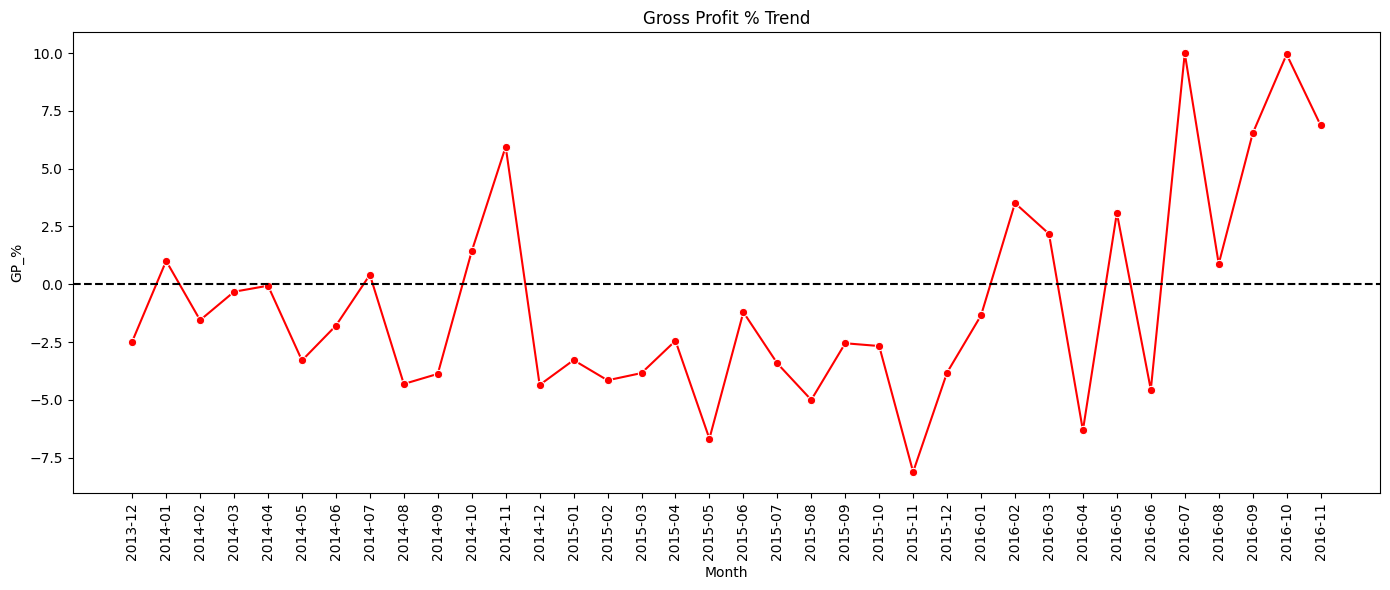

In [0]:
# ----------------------------------------------------------
# 9. GROSS PROFIT % TREND
# ----------------------------------------------------------

plt.figure(figsize=(14,6))

sns.lineplot(
    data=monthly,
    x='Month',
    y='GP_%',
    marker='o',
    color='red'
)

plt.axhline(0, color='black', linestyle='--')

plt.title('Gross Profit % Trend')
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

# INSIGHT:
# Highlights profitable and loss-making periods.

# Interpretation
- Positive GP% indicates profitable trading.
- Negative GP% indicates the company is selling products below cost or operating with very thin margins.
- Frequent negative GP% periods suggest profitability challenges.
- Management should review pricing and cost structures to improve margins.

# Business Insight

Although promotions increase sales volumes, they can reduce profitability if selling prices fall below sustainable levels

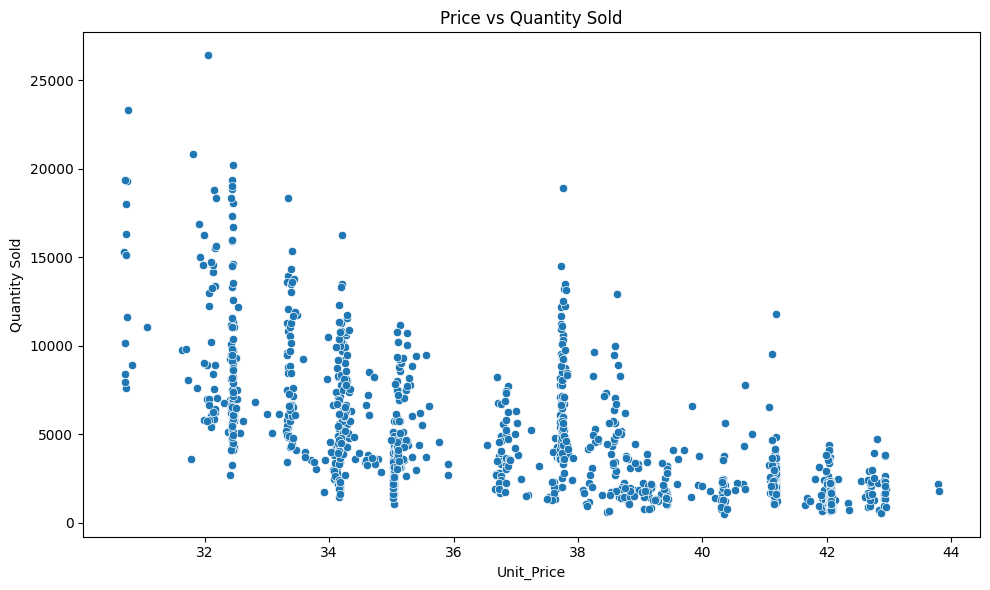

In [0]:
# ----------------------------------------------------------
# 10. PRICE VS QUANTITY SOLD
# ----------------------------------------------------------

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='Unit_Price',
    y='Quantity Sold'
)

plt.title('Price vs Quantity Sold')

plt.tight_layout()
plt.show()

# INSIGHT:
# Used to assess price elasticity of demand.

# Interpretation
- A downward pattern indicates an inverse relationship between price and demand.
- High quantities sold when prices are low suggest customers are price-sensitive.
- If quantities remain stable despite price increases, the product may be less price-sensitive.

#Business Insight

The scatter plot supports the conclusion that demand is elastic, meaning customers purchase more when prices decrease.Therefore making Pricing a critical factor influencing sales performance.

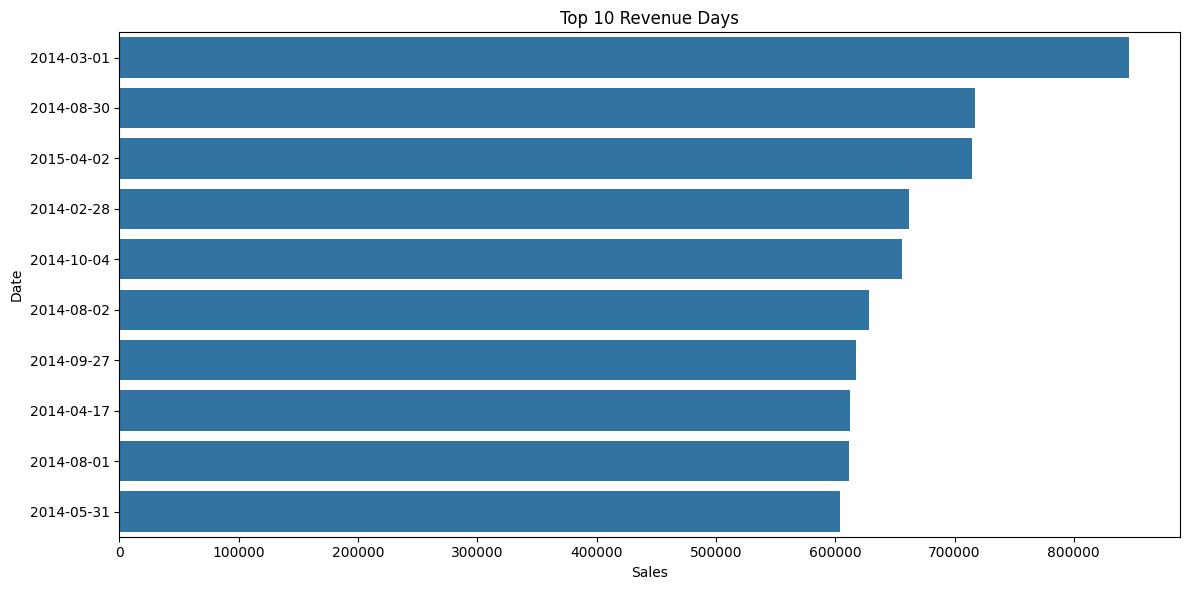

In [0]:
# ----------------------------------------------------------
# 11. TOP 10 SALES DAYS
# ----------------------------------------------------------

top10 = (
    df.nlargest(10, 'Sales')
    [['Date','Sales']]
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x='Sales',
    y=top10['Date'].dt.strftime('%Y-%m-%d')
)

plt.title('Top 10 Revenue Days')

plt.tight_layout()
plt.show()

# INSIGHT:
# Shows strongest trading days.

# Interpretation
- These dates represent the company's best trading days.
- Peak sales may be associated with promotions, seasonality, holidays, or special events.
- Understanding what happened during these periods can help replicate success.

# Business Insight

Management should analyse marketing activities and customer behaviour during peak sales periods to identify growth opportunities.

/home/spark-bfc07cdb-da0d-4343-beec-fa/.ipykernel/83/command-7176506631488153-2532385570:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


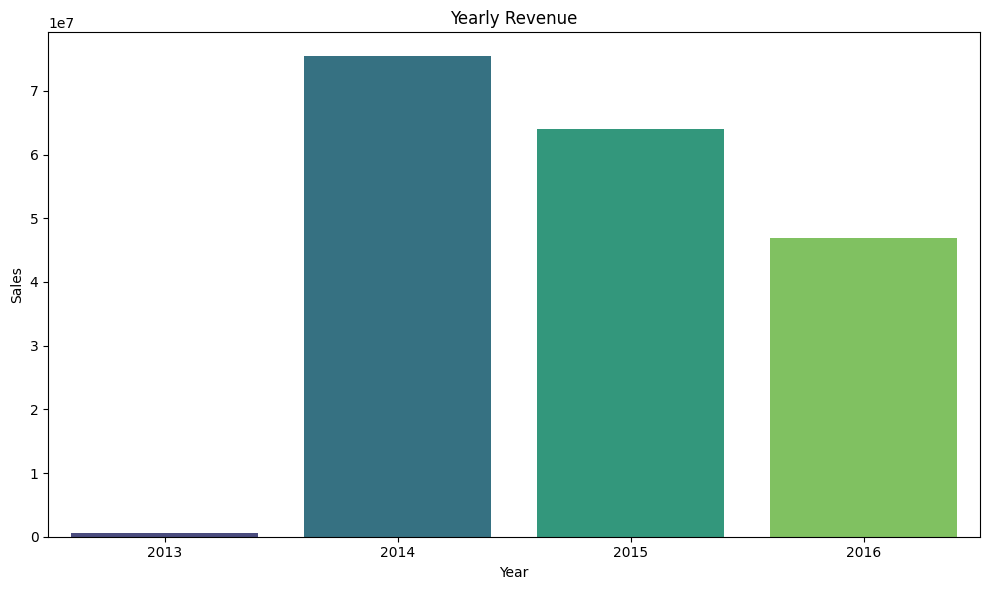

In [0]:
# ----------------------------------------------------------
# 12. YEARLY PERFORMANCE
# ----------------------------------------------------------

df['Year'] = df['Date'].dt.year

yearly = (
    df.groupby('Year')
    .agg({
        'Sales':'sum'
    })
    .reset_index()
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=yearly,
    x='Year',
    y='Sales',
    palette='viridis'
)

plt.title('Yearly Revenue')

plt.tight_layout()
plt.show()

# INSIGHT:
# Compare annual performance.

# Interpretation
- Enables comparison of company performance across years.
- A declining trend may indicate loss of market share or reduced customer spending.
- Growth suggests successful pricing, sales, and marketing strategies.

# Business Insight

Comparing annual performance reveals long-term business trends and helps evaluate strategic effectiveness.

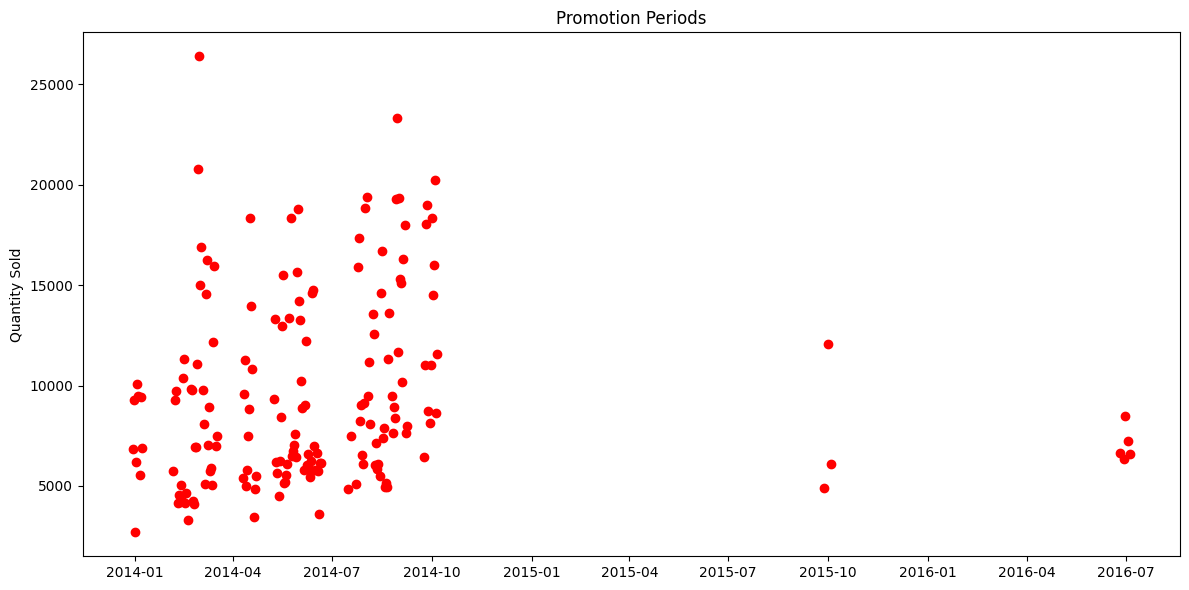

In [0]:
# ----------------------------------------------------------
# 13. PROMOTION IDENTIFICATION
# ----------------------------------------------------------

average_price = df['Unit_Price'].mean()

promotion = df[
    df['Unit_Price']
    < average_price * 0.90
]

plt.figure(figsize=(12,6))

plt.scatter(
    promotion['Date'],
    promotion['Quantity Sold'],
    color='red'
)

plt.title('Promotion Periods')
plt.ylabel('Quantity Sold')

plt.tight_layout()
plt.show()

# INSIGHT:
# Lower price periods can be compared with
# higher sales volume periods.

# Interpretation
- Promotions generally result in increased quantities sold.
- The business experiences significantly higher customer demand when products are discounted.
- However, promotions should be evaluated alongside profit margins.

# Business Insight

Promotional pricing is effective at driving demand but must be balanced against profitability objectives.

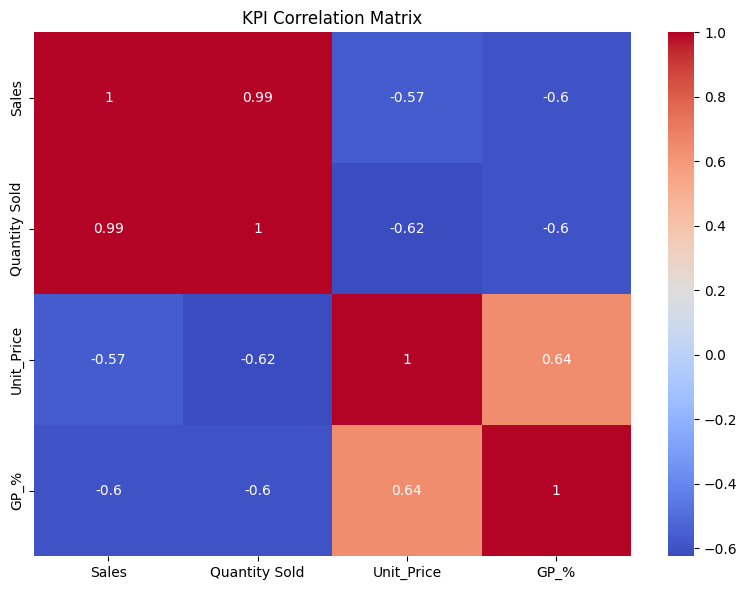

In [0]:
# ----------------------------------------------------------
# 14. CORRELATION HEATMAP
# ----------------------------------------------------------

corr_cols = [
    'Sales',
    'Quantity Sold',
    'Unit_Price',
    'GP_%'
]

plt.figure(figsize=(8,6))

sns.heatmap(
    df[corr_cols].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('KPI Correlation Matrix')

plt.tight_layout()
plt.show()

# INSIGHT:
# Identifies relationships between KPIs.

# Interpretation
- Sales vs Quantity Sold: Strong positive correlation indicates that selling more units increases revenue.
- Unit Price vs Quantity Sold: Negative correlation supports price elasticity.As price increases, quantity sold tends to decrease.
- GP% vs Sales: Helps determine whether higher revenues lead to better profitability.

# Business Insight

The heatmap quickly identifies the factors that most influence revenue and profitability.

# Key Findings

- Average selling price is R37.07 per unit.
- Daily selling prices fluctuate, indicating occasional promotions.
- Gross profit percentage can be monitored daily to identify low-margin periods.
- Promotional periods generally produce higher demand, demonstrating that customers are price sensitive.
- Extremely high elasticity values suggest that promotions have a significant impact on purchasing behaviour.
- A management dashboard showing Revenue, Quantity Sold, Average Selling Price, Gross Margin, and Monthly Trends would provide valuable operational insights.